In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import healpy as hp
import os, h5py
import tensorflow as tf
from icecream import ic

from msfm.utils import files
from msfm.utils.input_output import read_yaml

23-12-20 16:46:52   imports.py INF   Setting up healpy to run on 8 CPUs 


In [3]:
conf_dir = "../../configs/config.yaml"
conf = read_yaml(conf_dir)

n_side = conf["analysis"]["n_side"]
n_pix = conf["analysis"]["n_pix"]

data_vec_pix, _, _, _ = files.load_pixel_file()

23-12-20 16:46:52     files.py INF   Loaded the pixel file /cluster/home/athomsen/dlss/repos/multiprobe-simulation-forward-model/data/DESY3_pixels_512.h5 


# combined probes

In [22]:
# data_vector_dir = "/Users/arne/data/CosmoGrid_example/DES/grid/v2/cosmo_000001"
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/cosmo_fiducial"
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/debug/v3/fiducial/cosmo_fiducial"
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/v5/debug/cosmo_000001"
# data_vector_dir = "/cluster/work/refregier/athomsen/CosmoGrid/DESY3/v6/linear_bias/grid/cosmo_000001"
# data_vector_dir = "/cluster/work/refregier/athomsen/CosmoGrid/DESY3/v6/linear_bias/fiducial/cosmo_fiducial"
# data_vector_dir = "/cluster/work/refregier/athomsen/CosmoGrid/DESY3/v6/linear_bias/fiducial/cosmo_delta_s8_p"

data_vector_file = "data_vectors_nobaryons.h5"

# fix indices
i_noise = 0
j_min = 50
j_max = 60
with h5py.File(os.path.join(data_vector_dir, data_vector_file), "r") as f:
    ic(f.keys())
    # lensing
    kg = f["kg"][j_min:j_max]
    ia = f["ia"][j_min:j_max]
    sn = f["sn"][j_min:j_max,i_noise]
    # ct = f["ct"][:j_max]
    # clustering
    dg = f["dg"][j_min:j_max]

# check shapes
ic(kg.shape)
ic(dg.shape)
# assert kg.shape[:-1] == ia.shape[:-1] == sn.shape[:-1] == ct.shape[:-1]== dg.shape[:-1]
assert kg.shape[:-1] == ia.shape[:-1] == sn.shape[:-1] == dg.shape[:-1]

# constants
n_examples = kg.shape[0]
n_dv = kg.shape[1]

# bundle the maps
# all_maps = [kg, ia, sn, ct, dg]
# map_types = ["kg", "ia", "sn", "ct", "dg"]
# long_map_types = ["lensing signal", "intrinsic alignment", "shape noise", "galaxy count (Metacal)", "delta galaxy (Maglim)"]

all_maps = [kg, ia, sn, dg]
map_types = ["kg", "ia", "sn", "dg"]
long_map_types = ["lensing signal", "intrinsic alignment", "shape noise", "delta galaxy (Maglim)"]


n_types = len(map_types)

ic| f.keys(): <KeysViewHDF5 ['dg', 'ia', 'kg']>


KeyError: "Unable to open object (object 'sn' doesn't exist)"

In [14]:
# n_examples = 10

# dg_examples = np.zeros((n_examples, n_pix))
# dg_examples[:,data_vec_pix] = dg[:n_examples,:,0]


In [15]:
# dg_example = np.zeros(n_pix)
# dg_example[data_vec_pix] = dg[0,:,0]

# np.random.seed(11)
# Cls = np.arange(1, 1500)**-3.0

# sys_example = hp.synfast(cls=Cls, nside=n_side)
# sys_example -= np.mean(sys_example) + 1

In [16]:
# n_bar = 7
# b_g = 1.5
# l_max = 500

# smoothed_last = hp.smoothing(n_bar * (1 + b_g * dg_example) * sys_example, fwhm=np.pi/l_max)

# sys_smoothed = hp.smoothing(sys_example, fwhm=np.pi/l_max)
# dg_x_sys_smoothed = hp.smoothing(sys_example*dg_example, fwhm=np.pi/l_max)

# smoothed_first = n_bar * sys_smoothed + n_bar * b_g * dg_x_sys_smoothed

# hp.mollview(smoothed_last - smoothed_first, nest=False)

In [17]:
# convergence = kg + ia + sn

# for i in range(16):
#     print(np.std(convergence[:i], axis=(0,1)))

In [18]:
# convergence = kg + ia + sn
# print(convergence.shape)

# print(np.std(convergence, axis=(0,1)))

# kg *= 100
# ia *= 100
# sn *= 100

# convergence = kg + ia + sn

# print(np.std(convergence, axis=(0,1)))


In [19]:
square_pix = 500
reso = 1

all_gnoms = []
for maps in all_maps:
    n_tomos = maps.shape[-1]

    current_gnom = np.zeros((n_examples, square_pix, square_pix, n_tomos))

    for i in range(n_examples):
        for j in range(n_tomos):
            hp_map = np.zeros(n_pix)
            hp_map[data_vec_pix] = maps[i,:,j]

            current_gnom[i, :, :, j] = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)

    all_gnoms.append(current_gnom)

### vary tomographic bin, fix example

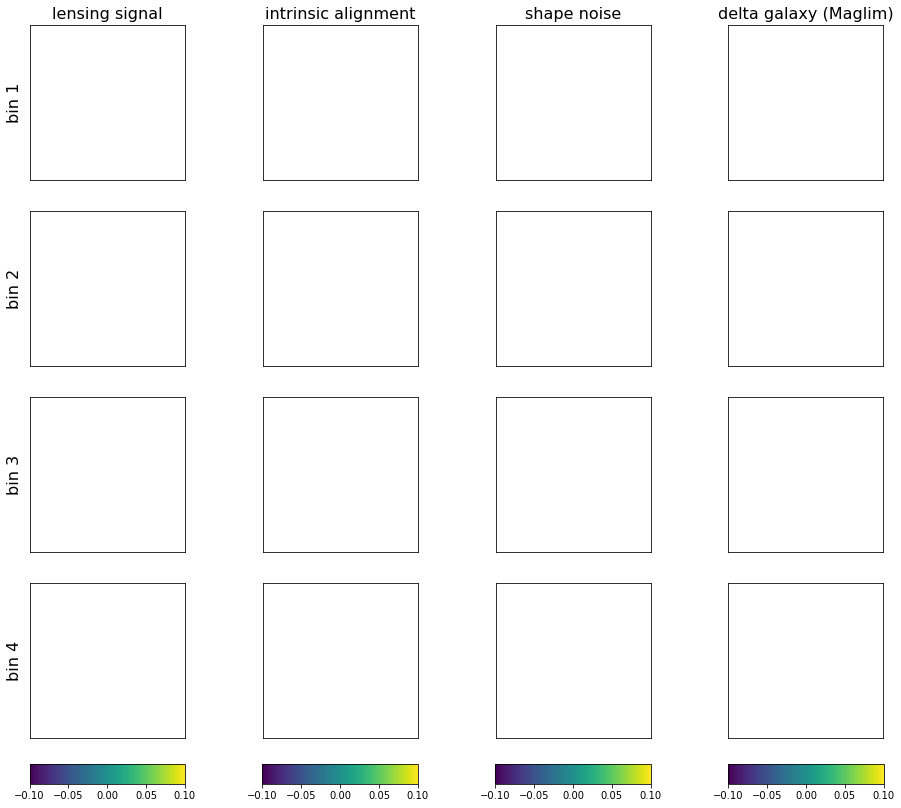

In [20]:
# fix the patch
example_id = 0

n_lens_z = 4
n_clust_z = 4

fig, ax = plt.subplots(figsize=(4*n_types, 4*n_clust_z), nrows=n_clust_z, ncols=n_types, sharex=True, sharey=True)

# loop over map types
for i, (gnoms, map_type) in enumerate(zip(all_gnoms, long_map_types)):
    n_z_bins = gnoms.shape[-1]

    for j in range(n_clust_z):
        # fix the example
        vmin = np.nanmin(gnoms[example_id])
        vmax = np.nanmax(gnoms[example_id])

        if j < n_z_bins:
            # fix the example, tomographic bin
            gnom = gnoms[example_id,:,:,j]
            gnom = np.ma.masked_where(gnom==0, gnom)

            im = ax[j,i].imshow(gnom, vmin=vmin, vmax=vmax)
        else:
            ax[j,i].axis("off")

        # cosmetics
        ax[j,i].set_xticks([])
        ax[j,i].set_yticks([])

        if j==0:
            ax[j,i].set_title(label=long_map_types[i], fontsize=16)

        if j==n_clust_z-1:
            fig.colorbar(im, ax=ax[:,i], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03, location="bottom")

        if i == 0:
            # ax[j,i].yaxis.set_label_position("right")
            ax[j,i].set_ylabel(ylabel=f"bin {j+1}", fontsize=16)


### vary example, fix tomographic bin

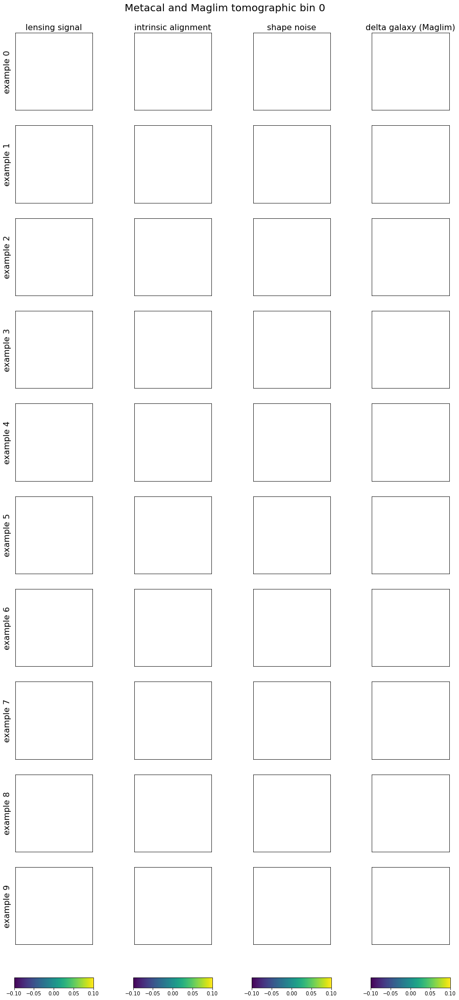

In [21]:
# fix the tomographic bin
tomo_id = 0

fig, ax = plt.subplots(figsize=(4*n_types, 4*n_examples), nrows=n_examples, ncols=n_types, sharex=True, sharey=True)

fig.suptitle(f"Metacal and Maglim tomographic bin {tomo_id}", y=0.9, fontsize=20)
for i in range(n_examples):
    for j, (gnoms, map_type) in enumerate(zip(all_gnoms, long_map_types)):

        # fix the tomographic bin
        vmin = np.nanmin(gnoms[:,:,:,tomo_id])
        vmax = np.nanmax(gnoms[:,:,:,tomo_id])

        # fix the tomographic bin and example
        gnom = gnoms[i,:,:,tomo_id]
        gnom = np.ma.masked_where(gnom==0, gnom)

        im = ax[i,j].imshow(gnom, vmin=vmin, vmax=vmax)

        # cosmetics
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

        if i==0:
            ax[i,j].set_title(label=long_map_types[j], fontsize=16)

        if j==0:
            ax[i,j].set_ylabel(ylabel=f"example {i}", fontsize=16)

        if i==(n_examples-1):
            fig.colorbar(im, ax=ax[:,j], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)

# weak lensing

In [4]:
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/DESY3/v1/cosmo_delta_H0_m"
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/v1/fiducial/cosmo_fiducial"
# data_vector_dir = "/Users/arne/data/CosmoGrid_example/DES/grid/v1/cosmo_000001"
data_vector_dir = "/Users/arne/data/CosmoGrid_example/DES/grid/v2/cosmo_000001"
data_vector_file = "data_vectors_nobaryons.h5"

i_noise = 0
j_max = 100
with h5py.File(os.path.join(data_vector_dir, data_vector_file), "r") as f:
    ic(f.keys())
    kg = f["kg"][:j_max]
    ia = f["ia"][:j_max]
    sn = f["sn"][:j_max,i_noise]
#     ct = f["ct"][:]

    all_sn = f["sn"][:j_max,:3]

ic(kg.shape)
ic(all_sn.shape)

all_maps = np.stack([kg, ia, sn])
# maps = np.stack([kg, ia, sn, ct])
ic(all_maps.shape)

n_types = all_maps.shape[0]
n_examples = all_maps.shape[1]
n_dv = all_maps.shape[2]
n_tomos = all_maps.shape[3]
n_noise = all_sn.shape[1]

ic| f.keys(): <KeysViewHDF5 ['ct', 'ia', 'kg', 'sn']>
ic| kg.shape: (16, 463872, 4)
ic| all_sn.shape: (16, 1, 463872, 4)
ic| maps.shape: (3, 16, 463872, 4)


# mean is close to zero

In [43]:
print(kg.shape)
print(np.mean(kg, axis=1))

(16, 463872, 4)
[[-6.4434465e-11 -9.4845035e-11  2.9979658e-10  4.4341631e-11]
 [ 2.3701071e-12 -1.7283110e-10 -4.1572240e-10  4.8518428e-10]
 [-8.3098334e-11 -3.9932507e-10 -1.1006743e-10 -1.2833468e-09]
 [-3.7490017e-10  6.9811923e-10 -9.5972022e-11  7.6260542e-10]
 [ 9.4791543e-11 -2.5447952e-10 -4.6416856e-11  9.2420904e-11]
 [ 5.4273647e-10 -7.1939926e-10 -4.4629386e-10  1.3136451e-09]
 [ 2.0483159e-12  1.7810912e-10 -3.2664613e-10  4.7945803e-10]
 [-4.4279241e-10 -6.8425425e-11 -3.7641404e-10 -4.8002446e-10]
 [-1.4372225e-11 -2.0532094e-10 -1.3203133e-10 -1.8430819e-11]
 [ 2.3145234e-10 -8.2221938e-11 -3.2317882e-10 -4.2512321e-10]
 [ 1.1038666e-10 -2.3231768e-10 -3.1241446e-10  2.8372821e-10]
 [ 1.2748284e-10  1.0203908e-10  4.8195387e-10  2.9962630e-10]
 [-5.3934190e-10  1.6620715e-10  2.7436273e-10  3.2158567e-11]
 [-9.2079816e-11 -4.5211723e-11  1.5485904e-10 -2.7818492e-10]
 [-1.7250487e-11 -1.8981432e-10  3.9521736e-10  2.8652244e-10]
 [-1.7910495e-10  2.6781707e-10 -6.1287

In [5]:
# map_types = ["kg", "ia", "sn", "ct"]
map_types = ["kg", "ia", "sn"]
long_map_types = ["lensing signal", "intrinsic alignment", "shape noise"]
# long_map_types = ["lensing signal", "intrinsic alignment", "shape noise", "galaxy counts"]
tomos = np.arange(4)

## gnomview

In [6]:
square_pix = 500
reso = 1

all_types_gnom = np.zeros((n_types, n_examples, square_pix, square_pix, n_tomos))
for i in range(n_types):
    for j in range(n_examples):
        for k in range(n_tomos):
            hp_map = np.zeros(n_pix)
            hp_map[data_vec_pix] = all_maps[i,j,:,k]

            all_types_gnom[i,j,:,:,k] = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)

### tomo

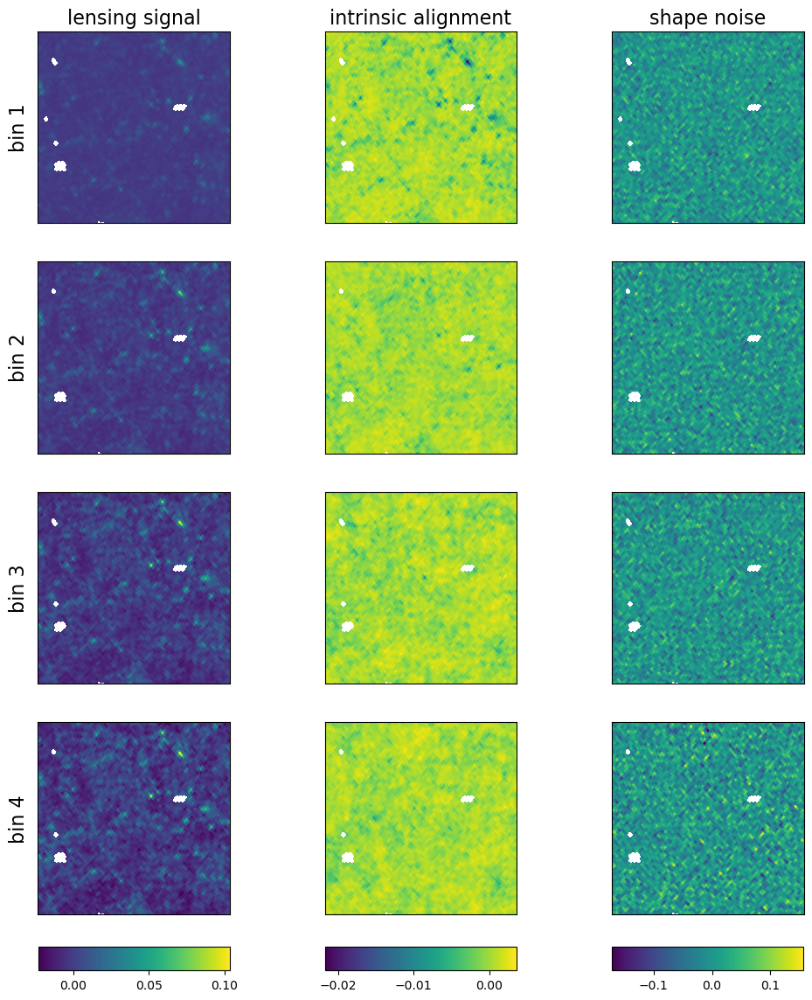

In [7]:
# fix the patch
example_id = 7

fig, ax = plt.subplots(figsize=(4*n_types, 4*n_tomos), nrows=n_tomos, ncols=n_types, sharex=True, sharey=True)

for i in range(n_tomos):        
    for j, map_type in enumerate(long_map_types):
        # over all axis but the map type and fixed patch
        vmin = np.nanmin(all_types_gnom[j,example_id])
        vmax = np.nanmax(all_types_gnom[j,example_id])

        gnoms = all_types_gnom[j,example_id,:,:,i]
        gnoms = np.ma.masked_where(gnoms==0, gnoms)

        im = ax[i,j].imshow(gnoms, vmin=vmin, vmax=vmax)

        # cosmetics
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

        if i==0:
            ax[i,j].set_title(label=long_map_types[j], fontsize=16)

        if j==0:
            ax[i,j].set_ylabel(ylabel=f"bin {i+1}", fontsize=16)

        if i==(n_tomos-1):
            fig.colorbar(im, ax=ax[:,j], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)

flip rows and colums

In [8]:
# # fix the patch
# patch_id = 0

# fig, ax = plt.subplots(figsize=(4*n_tomos+4, 4*n_types), nrows=n_types, ncols=n_tomos, sharex=True, sharey=True)

# for i, map_type in enumerate(long_map_types):
#     # over all axis but the map type and fixed patch
#     vmin = np.nanmin(gnoms[i,patch_id])
#     vmax = np.nanmax(gnoms[i,patch_id])

#     for j in range(n_tomos):
#         gnom = gnoms[i,patch_id,:,:,j]

#         im = ax[i,j].imshow(gnom, vmin=vmin, vmax=vmax)

#         # cosmetics
#         ax[i,j].set_xticks([])
#         ax[i,j].set_yticks([])

#         if i==0:
#             ax[i,j].set_title(label=f"bin {j+1}", fontsize=16)

#         if j==0:
#             ax[i,j].set_ylabel(ylabel=long_map_types[i], fontsize=16)

#         if j==(n_tomos-1):
#             fig.colorbar(im, ax=ax[i,:], orientation="vertical", shrink=0.8, aspect=8, pad=0.03)

### patches

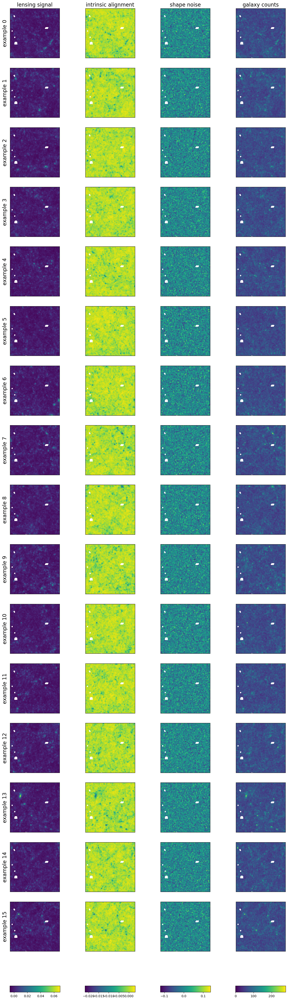

In [9]:
# fix the tomographic bin
tomo_id = 0

fig, ax = plt.subplots(figsize=(4*n_types, 4*n_examples), nrows=n_examples, ncols=n_types, sharex=True, sharey=True)

for i in range(n_examples):
    for j, map_type in enumerate(long_map_types):
        # over all axis but the map type and fixed tomographic bin
        vmin = np.nanmin(all_types_gnom[j,:,:,:,tomo_id])
        vmax = np.nanmax(all_types_gnom[j,:,:,:,tomo_id])

        gnom = all_types_gnom[j,i,:,:,tomo_id]
        gnom = np.ma.masked_where(gnom==0, gnom)

        im = ax[i,j].imshow(gnom, vmin=vmin, vmax=vmax)

        # cosmetics
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

        if i==0:
            ax[i,j].set_title(label=long_map_types[j], fontsize=16)

        if j==0:
            ax[i,j].set_ylabel(ylabel=f"example {i}", fontsize=16)

        if i==(n_examples-1):
            fig.colorbar(im, ax=ax[:,j], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)

### noise realizations

In [10]:
i_tomo = 3

ct_gnoms = np.zeros((n_examples, square_pix, square_pix))
sn_gnoms = np.zeros((n_examples, n_noise, square_pix, square_pix))
for i in range(n_examples):
    hp_map = np.zeros(n_pix)
    hp_map[data_vec_pix] = ct[i,:,i_tomo]
    ct_gnoms[i] = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)
    
    for j in range(n_noise):
        hp_map = np.zeros(n_pix)
        hp_map[data_vec_pix] = all_sn[i,j,:,i_tomo]
        sn_gnoms[i,j] = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)

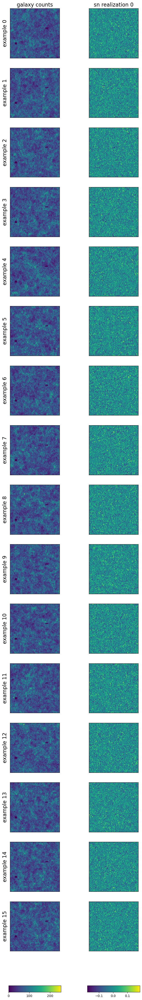

In [11]:
sn_vmin = np.nanmin(sn_gnoms)
sn_vmax = np.nanmax(sn_gnoms)
ct_vmin = np.nanmin(ct_gnoms)
ct_vmax = np.nanmax(ct_gnoms)

fig, ax = plt.subplots(figsize=(4*(1+n_noise), 4*n_examples), nrows=n_examples, ncols=1+n_noise, sharex=True, sharey=True)

for i in range(n_examples):
    for j in range(n_noise):
        if j==0:
            # include galaxy counts
            hp_map = np.zeros(n_pix)
            hp_map[data_vec_pix] = ct[i,:,i_tomo]
            sn_gnom = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)
            
            im = ax[i,j].imshow(ct_gnoms[i], vmin=ct_vmin, vmax=ct_vmax)

            if i==0:
                ax[i,j].set_title(f"galaxy counts", fontsize=16)
            if i==(n_examples-1):
                fig.colorbar(im, ax=ax[:,j], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)

        im = ax[i,j+1].imshow(sn_gnoms[i,j], vmin=sn_vmin, vmax=sn_vmax)

        # cosmetics 
        ax[i,j].set_xticks([])
        ax[i,j].set_yticks([])

        # if i==0 and j==0:
        #     ax[i,j].set_title(f"galaxy counts", fontsize=16)
        # elif i==0:
        #     ax[i,j].set_title(f"sn realization {j}", fontsize=16)

        if i==0:
            ax[i,j+1].set_title(f"sn realization {j}", fontsize=16)

        if j==0:
            ax[i,j].set_ylabel(ylabel=f"example {i}", fontsize=16)

        if i==(n_examples-1):
            fig.colorbar(im, ax=ax[:,j+1], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)
            

## mollview

### tomo

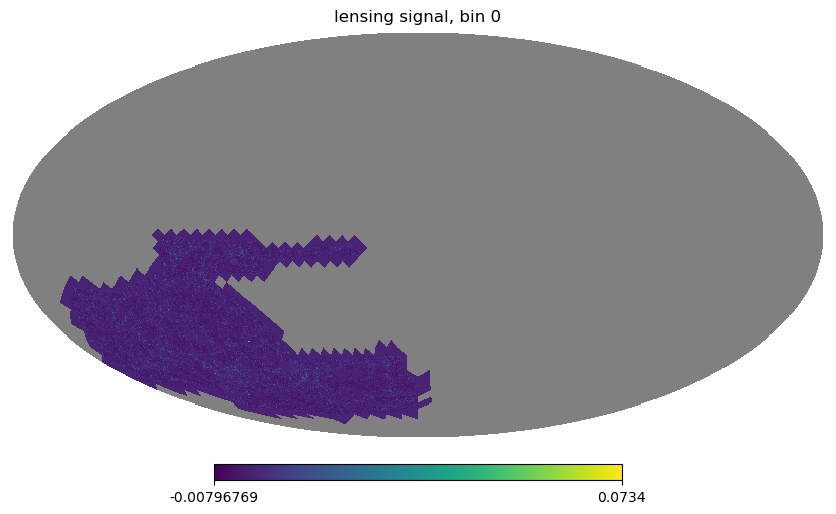

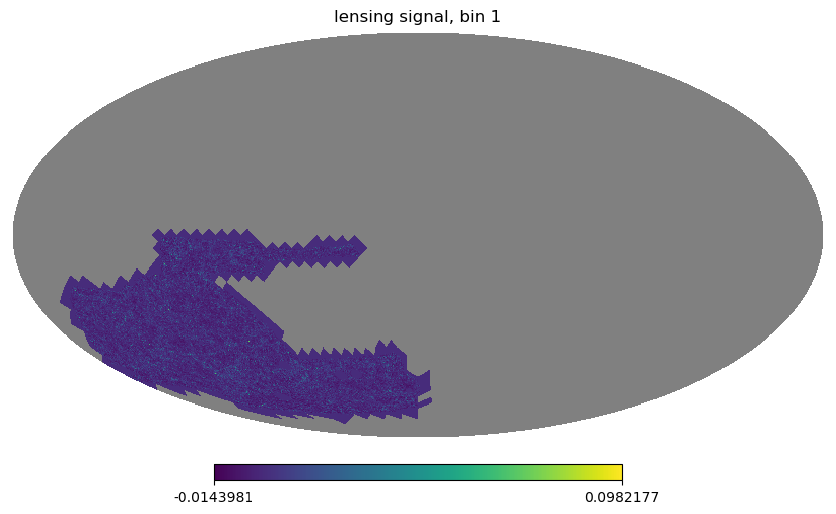

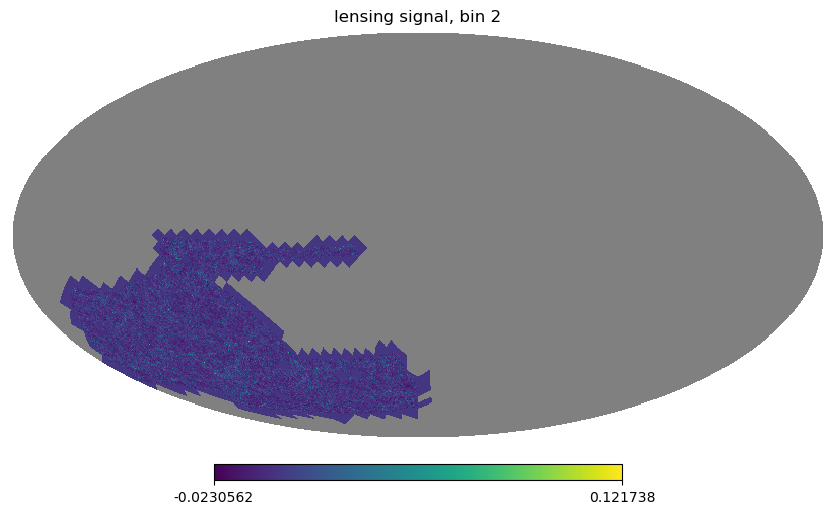

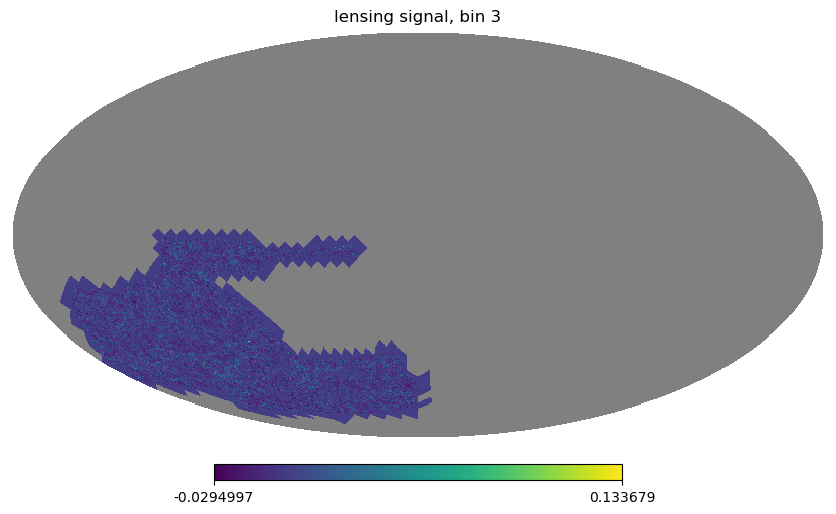

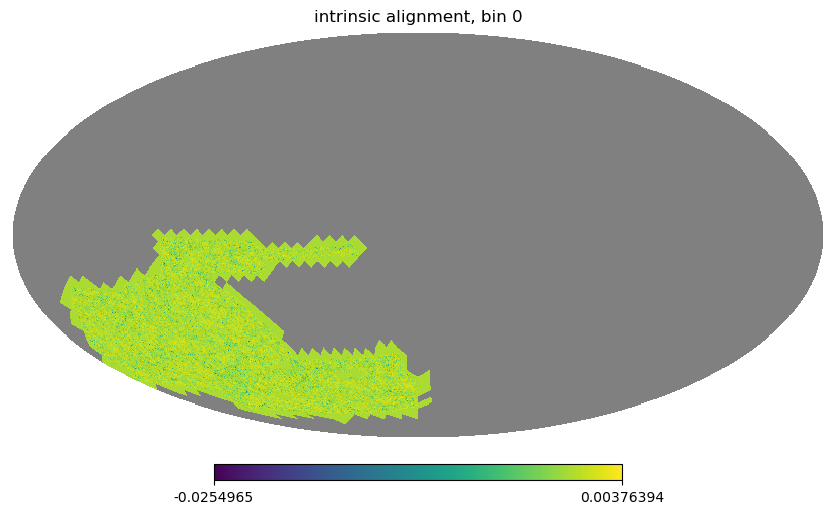

...

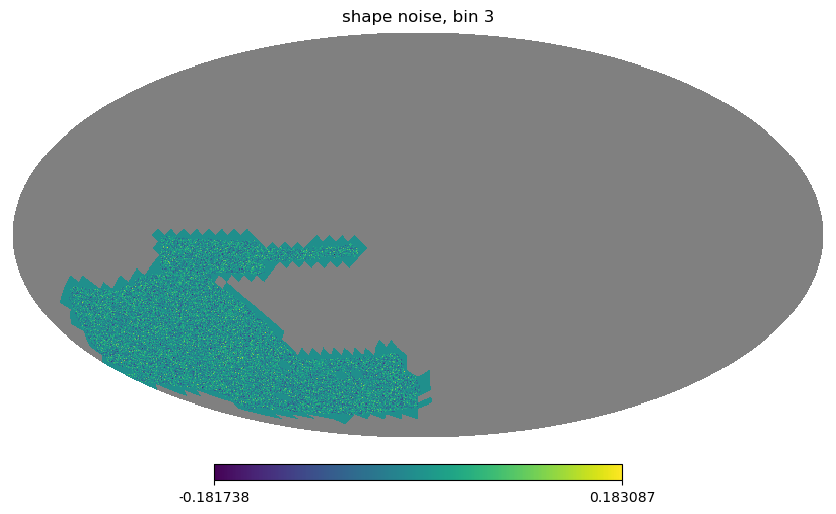

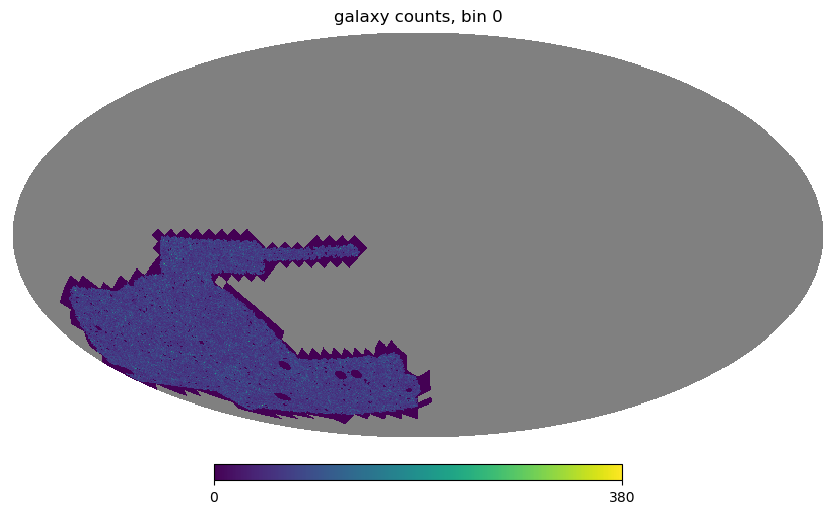

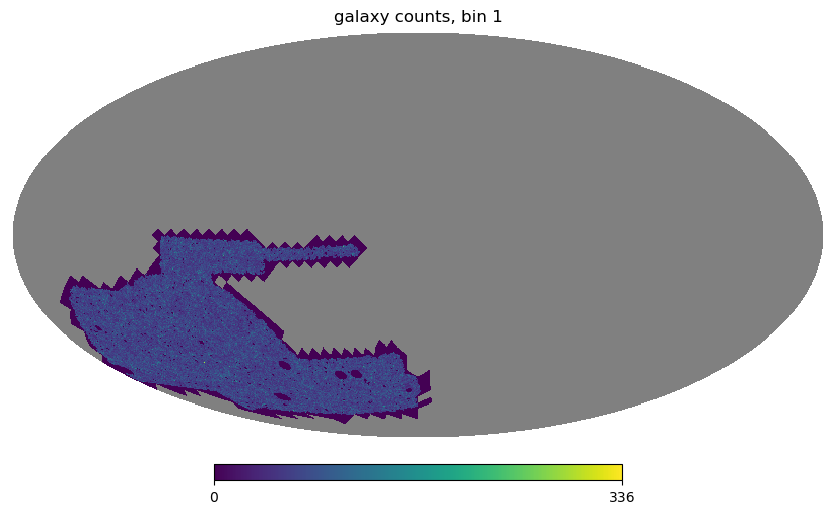

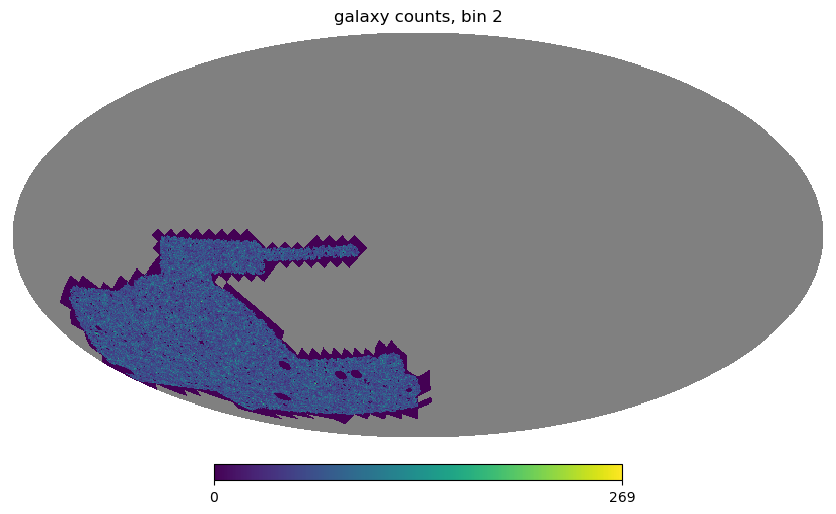

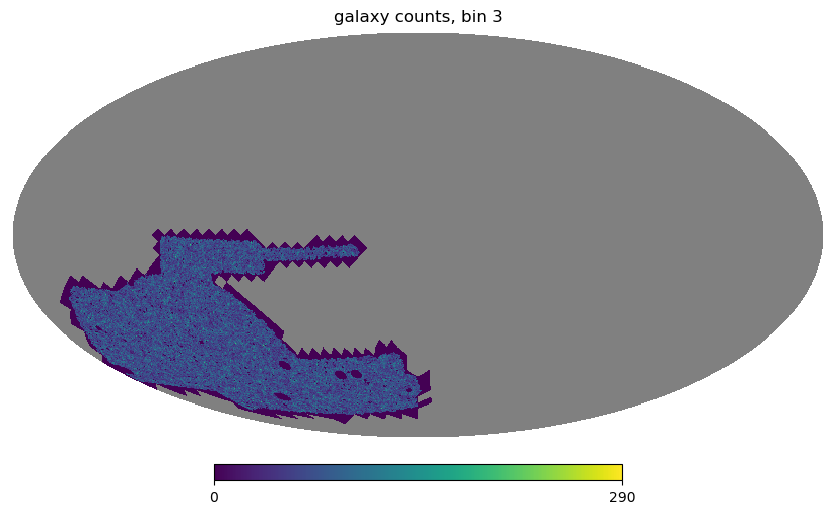

In [12]:
# fix the patch
patch_id = 0

for i, map_type in enumerate(long_map_types):
    for j in range(n_tomos):
        vmin = np.nanmin(all_maps[i,patch_id,:,j])
        vmax = np.nanmax(all_maps[i,patch_id,:,j])

        hp_map = np.full(n_pix, hp.UNSEEN)
        hp_map[data_vec_pix] = all_maps[i,patch_id,:,j]

        hp.mollview(hp_map, title=f"{map_type}, bin {j}", nest=True, min=vmin, max=vmax)

# fiducial perturbations

In [4]:
# data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/v1/fiducial/cosmo_fiducial"
data_vector_dir = "/cluster/scratch/athomsen/CosmoGrid/v1/fiducial/cosmo_delta_H0_m"
data_vector_file = "data_vectors_nobaryons.h5"

i_noise = 0
with h5py.File(os.path.join(data_vector_dir, data_vector_file), "r") as f:
    ic(f.keys())
    kg = f["kg"][:]

ic(kg.shape)

n_examples = kg.shape[0]
n_dv = kg.shape[1]
n_tomos = kg.shape[2]

ic| f.keys(): <KeysViewHDF5 ['kg']>
ic| kg.shape: (12, 463872, 4)


In [5]:
square_pix = 500
reso = 1

all_types_gnom = np.zeros((n_examples, square_pix, square_pix, n_tomos))
for i in range(n_examples):
    for j in range(n_tomos):
        hp_map = np.zeros(n_pix)
        hp_map[data_vec_pix] = kg[i,:,j]

        all_types_gnom[i,:,:,j] = hp.gnomview(hp_map, nest=True, rot=(90, -30, 0), reso=reso, return_projected_map=True, no_plot=True, xsize=square_pix, ysize=square_pix)

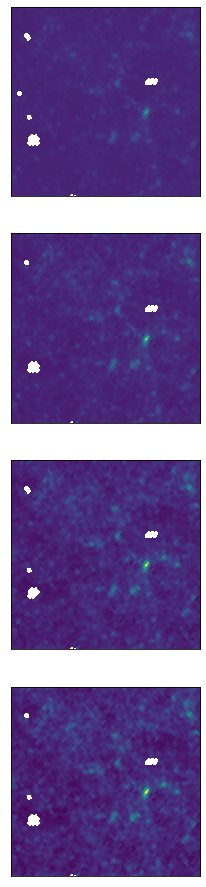

In [7]:
# fix the patch
patch_id = 3

fig, ax = plt.subplots(figsize=(4, 4*n_tomos), nrows=n_tomos, ncols=1, sharex=True, sharey=True)

for i in range(n_tomos):        
    # over all axis but the map type and fixed patch
    vmin = np.nanmin(all_types_gnom[patch_id])
    vmax = np.nanmax(all_types_gnom[patch_id])

    gnom = all_types_gnom[patch_id,:,:,i]
    gnom = np.ma.masked_where(gnom==0, gnom)

    im = ax[i].imshow(gnom, vmin=vmin, vmax=vmax)

    # cosmetics
    ax[i].set_xticks([])
    ax[i].set_yticks([])

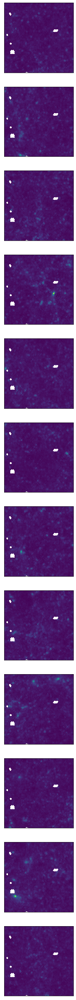

In [8]:
# fix the tomographic bin
tomo_id = 0

fig, ax = plt.subplots(figsize=(4*1, 4*n_examples), nrows=n_examples, ncols=1, sharex=True, sharey=True)

for i in range(n_examples):
    # over all axis but the map type and fixed tomographic bin
    vmin = np.nanmin(all_types_gnom[:,:,:,tomo_id])
    vmax = np.nanmax(all_types_gnom[:,:,:,tomo_id])

    gnom = all_types_gnom[i,:,:,tomo_id]
    gnom = np.ma.masked_where(gnom==0, gnom)

    im = ax[i].imshow(gnom, vmin=vmin, vmax=vmax)

    # cosmetics
    ax[i].set_xticks([])
    ax[i].set_yticks([])

#     if i==0:
#         ax[i,j].set_title(label=long_map_types[j], fontsize=16)

#     if j==0:
#         ax[i,j].set_ylabel(ylabel=f"example {i}", fontsize=16)

#     if i==(n_examples-1):
#         fig.colorbar(im, ax=ax[:,j], orientation="horizontal", shrink=0.8, aspect=8, pad=0.03)

# debug

In [13]:
# data_vector_dir = "/Users/arne/data/CosmoGrid_example/DES/grid/noise_test/cosmo_000001"
# data_vector_file = "data_vectors.h5"

# with h5py.File(os.path.join(data_vector_dir, data_vector_file), "r") as f:
#     print(f.keys())
#     sn = f["sn"][:]

# print(sn.shape)

# n_patches = sn.shape[0]
# n_dv = sn.shape[1]
# n_tomos = sn.shape[2]

In [14]:
# for i in range(n_patches):
#     for j in range(n_tomos):
#         hp_map = np.full(n_pix, hp.UNSEEN)
#         hp_map[data_vec_pix] = sn[i,:,j]

#         hp.mollview(hp_map, title=f"patch {i+1}, bin {j+1}", nest=True)